In [1]:
import os
os.chdir("D:/文章返修/source data/Figure_5/Panel_G_and_H")
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import pandas as pd

In [10]:
def get_matrix_npz(M1,M2):
    '''
    transform a three tuple into a matrix
    '''
    S1 = sparse.coo_matrix((M1['value'],(np.asarray(M1['S'], dtype='<i4'),np.asarray(M1['E'], dtype= '<i4')))).toarray()
    S2 = sparse.coo_matrix((M2['value'],(np.asarray(M2['E'], dtype='<i4'),np.asarray(M2['S'], dtype= '<i4')))).toarray()
    matrix = np.zeros((max(S2.shape),max(S1.shape)))
    matrix[np.nonzero(S1)] = S1[np.nonzero(S1)]
    matrix[np.nonzero(S2)] = S2[np.nonzero(S2)]
    return matrix

def extract_matrix(file_dir, file_name, res):
    data = np.loadtxt(file_dir + file_name, usecols=[0,1,2], dtype=[('S','<i4'),('E','<i4'),('value','<f8')])
    data['S'] = data['S'] / res
    data['E'] = data['E'] / res
    data['value'][data['value'] < 0] = 0
    data['value'][np.isnan(data['value'])] = 0
    mat = get_matrix_npz(data, data)
    return mat

def select_strc(ct_f, s, e, types = 'varna'):
    strc_selet = ct_f[s-1:e].copy()
    mask = (strc_selet['5'] < s) | (strc_selet['5'] > e)
    strc_selet['5'][mask] = 0
    if types == 'rna_strc':
        strc_selet['1'] = strc_selet['1'] - s +1
        strc_selet['3'] = strc_selet['3'] - s +1
        strc_selet['4'] = strc_selet['4'] - s +1
        strc_selet['5'][strc_selet['5']>0] = strc_selet['5'][strc_selet['5']>0] - s +1
        strc_selet['6'] = strc_selet['6'] - s +1
    return strc_selet

res = 5
file_dir = "./"
color = 'grey'
stp = int(750 / res)
size = 7.5
vmax = 6

In [3]:
strc_sars_ric = np.loadtxt(file_dir + 'virus.phase4_final.whole.ct', usecols=[0,1,2,3,4,5], dtype=[('1','<i4'),('2','<U2'),('3','<i4'),('4','<i4'),('5','<i4'), ('6','<i4')], skiprows=1)

In [7]:
ma_sars_splash_382 = extract_matrix(file_dir, 'splash-SARS2-wanyue-382.1nt.none.matrix', res)
ma_sars_splash_382[int(27848/res):int(28229/res),:] = 0
ma_sars_splash_382[:,int(27848/res):int(28229/res)] = 0

ma_sars_splash_wt = extract_matrix(file_dir, 'splash-SARS2-wanyue-WT.1nt.none.matrix', res)

In [8]:
s1 = int(27250 / res)
e1 = int(29750 / res)
s2 = int(27250 / res)
e2 = int(29750 / res)

s = 27250
e = 29750
ric_1 = select_strc(strc_sars_ric, s, e)

mask_ric = ric_1['5'] > 0
col_ric = (ric_1['1'][mask_ric] - s ) / res
raw_ric = (ric_1['5'][mask_ric] - s ) / res

Text(0.5, 1.0, 'SPLASH-WT')

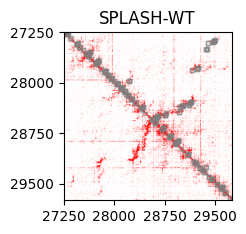

In [11]:
plt.subplot(223)
plt.imshow(ma_sars_splash_wt[s1:e1, s2:e2], cmap= plt.get_cmap('bwr'), vmax=vmax, vmin=0-vmax)
plt.yticks(np.arange(0,e1-s1,stp),np.arange(s1,e1,stp) * res)
plt.xticks(np.arange(0,e2-s2,stp),np.arange(s2,e2,stp) * res)
plt.scatter(raw_ric[col_ric < raw_ric],col_ric[col_ric < raw_ric],s = size, marker = 's', c ='none', edgecolors = color, alpha=0.25)
plt.title('SPLASH-WT')

Text(0.5, 1.0, 'SPLASH-382')

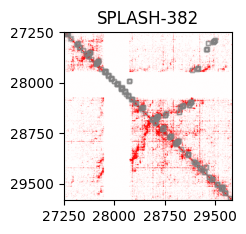

In [12]:
plt.subplot(224)
plt.imshow(ma_sars_splash_382[s1:e1, s2:e2], cmap= plt.get_cmap('bwr'), vmax=vmax, vmin=0-vmax)
plt.yticks(np.arange(0,e1-s1,stp),np.arange(s1,e1,stp) * res)
plt.xticks(np.arange(0,e2-s2,stp),np.arange(s2,e2,stp) * res)
plt.scatter(raw_ric[col_ric < raw_ric],col_ric[col_ric < raw_ric],s = size, marker = 's', c ='none', edgecolors = color, alpha=0.25)
plt.title('SPLASH-382')